In [50]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# Leitura do arquivo

caminho_arquivo = 'tratados_10x10det/photon/photon1E15_array'

df = pl.read_csv(caminho_arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("positrons"))
df = df.with_columns(pl.col("split_column").list.get(2).cast(pl.Int64).alias("electrons"))
df = df.with_columns(pl.col("split_column").list.get(3).cast(pl.Int64).alias("muons_plus"))
df = df.with_columns(pl.col("split_column").list.get(4).cast(pl.Int64).alias("muons_minus"))
df = df.with_columns(
    (pl.col("positrons") + pl.col("electrons") + pl.col("muons_plus") + pl.col("muons_minus")).alias("total_particles")
)

df

column_1,split_column,TRIG,positrons,electrons,muons_plus,muons_minus,total_particles
str,list[str],str,i64,i64,i64,i64,i64
"""TRIG1 0 0 0 0""","[""TRIG1"", ""0"", … ""0""]","""TRIG1""",0,0,0,0,0
"""TRIG2 0 0 0 0""","[""TRIG2"", ""0"", … ""0""]","""TRIG2""",0,0,0,0,0
"""TRIG3 0 0 0 0""","[""TRIG3"", ""0"", … ""0""]","""TRIG3""",0,0,0,0,0
"""TRIG4 0 0 0 0""","[""TRIG4"", ""0"", … ""0""]","""TRIG4""",0,0,0,0,0
"""TRIG5 0 0 0 0""","[""TRIG5"", ""0"", … ""0""]","""TRIG5""",0,0,0,0,0
…,…,…,…,…,…,…,…
"""TRIG96 0 0 0 0""","[""TRIG96"", ""0"", … ""0""]","""TRIG96""",0,0,0,0,0
"""TRIG97 0 0 0 0""","[""TRIG97"", ""0"", … ""0""]","""TRIG97""",0,0,0,0,0
"""TRIG98 0 0 0 0""","[""TRIG98"", ""0"", … ""0""]","""TRIG98""",0,0,0,0,0


In [52]:
import re
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Photon 1E15'

In [53]:
# Transformação das contagens de partículas em listas e na média de contagens

df2 = df.group_by('TRIG').agg(pl.col('total_particles')).sort(
    pl.col('TRIG').str.extract(r"TRIG([0-9]*)", 1).cast(int)
)
#df2 = df2.with_columns(mean_particles = pl.col('total_particles').list.mean())  
#df2

In [54]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

print("x_det:", x_det)
print("y_det:", y_det)
print("areas:", areas)


x_det: [-45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35.
 -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.
  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45.
 -45. -35. -25. -15.  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.
  -5.   5.  15.  25.  35.  45. -45. -35. -25. -15.  -5.   5.  15.  25.
  35.  45.]
y_det: [-45. -45. -45. -45. -45. -45. -45. -45. -45. -45. -35. -35. -35. -35.
 -35. -35. -35. -35. -35. -35. -25. -25. -25. -25. -25. -25. -25. -25.
 -25. -25. -15. -15. -15. -15. -15. -15. -15. -15. -15. -15.  -5.  -5.
  -5.  -5.  -5.  -5.  -5.  -5.  -5.  -5.   5.   5.   5.   5.   5.   5.
   5.   5.   5.   5.  15.  15.  15.  15.  15.  15.  15.  15.  15.  15.
  25.  25.  25.  25.  25.  25.  25.  25.  25.  25.  35.  35.  35.  35.
  35.  35.  35.  35.  35.  35.  45.  45.  45.  45. 

In [55]:
from scipy.spatial import KDTree

# Método KDTree 
positions = np.column_stack((x_det, y_det))
tree = KDTree(positions)
d_max = 15  # Distância máxima para considerar como próximos

# Validar simulações com triangulação
num_simulations = len(df2["total_particles"][0])

valid_simulations = []

for sim_idx in range(num_simulations):
    detections = np.array([df2["total_particles"][i][sim_idx] > 0 for i in range(100)])  

    detected_indices = np.where(detections)[0]
    if len(detected_indices) < 3:
        continue
    
    neighbors = []
    for tank in detected_indices:
        neighbors.append(set(tree.query_ball_point(positions[tank], d_max)))
    
    valid = False
    n = len(detected_indices)
    for i in range(n):
        tank_i = detected_indices[i]
        for j in range(i + 1, n):
            tank_j = detected_indices[j]
            if tank_j not in neighbors[i]:  
                continue
            for k in range(j + 1, n):
                tank_k = detected_indices[k]
                if tank_k in neighbors[i] and tank_k in neighbors[j]:
                    valid = True
                    break
            if valid:
                break
        if valid:
            break
    
    if valid:
        valid_simulations.append(sim_idx)


# Atualizar o dataframe
triangulation_particles = [
    [particles[i] for i in valid_simulations] for particles in df2["total_particles"]
]

triangulation_particles = df2.with_columns(
    pl.Series("triangulation_particles", triangulation_particles)
)

print(f"Simulações válidas: {len(valid_simulations)}")
triangulation_particles

Simulações válidas: 601


TRIG,total_particles,triangulation_particles
str,list[i64],list[i64]
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG2""","[0, 1, … 0]","[1, 0, … 0]"
"""TRIG3""","[0, 0, … 0]","[0, 2, … 0]"
"""TRIG4""","[0, 0, … 0]","[0, 2, … 0]"
"""TRIG5""","[0, 0, … 0]","[0, 0, … 1]"
…,…,…
"""TRIG96""","[0, 0, … 0]","[0, 0, … 1]"
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG98""","[0, 0, … 0]","[0, 0, … 0]"


In [56]:
triangulation_particles = triangulation_particles.with_columns(mean_particles = pl.col('triangulation_particles').list.mean())  
trigs = triangulation_particles['mean_particles'].to_list()
triangulation_particles

TRIG,total_particles,triangulation_particles,mean_particles
str,list[i64],list[i64],f64
"""TRIG1""","[0, 0, … 0]","[0, 0, … 0]",0.454243
"""TRIG2""","[0, 1, … 0]","[1, 0, … 0]",0.608985
"""TRIG3""","[0, 0, … 0]","[0, 2, … 0]",0.848586
"""TRIG4""","[0, 0, … 0]","[0, 2, … 0]",0.9401
"""TRIG5""","[0, 0, … 0]","[0, 0, … 1]",1.069884
…,…,…,…
"""TRIG96""","[0, 0, … 0]","[0, 0, … 1]",1.153078
"""TRIG97""","[0, 0, … 0]","[0, 0, … 0]",0.983361
"""TRIG98""","[0, 0, … 0]","[0, 0, … 0]",0.84193


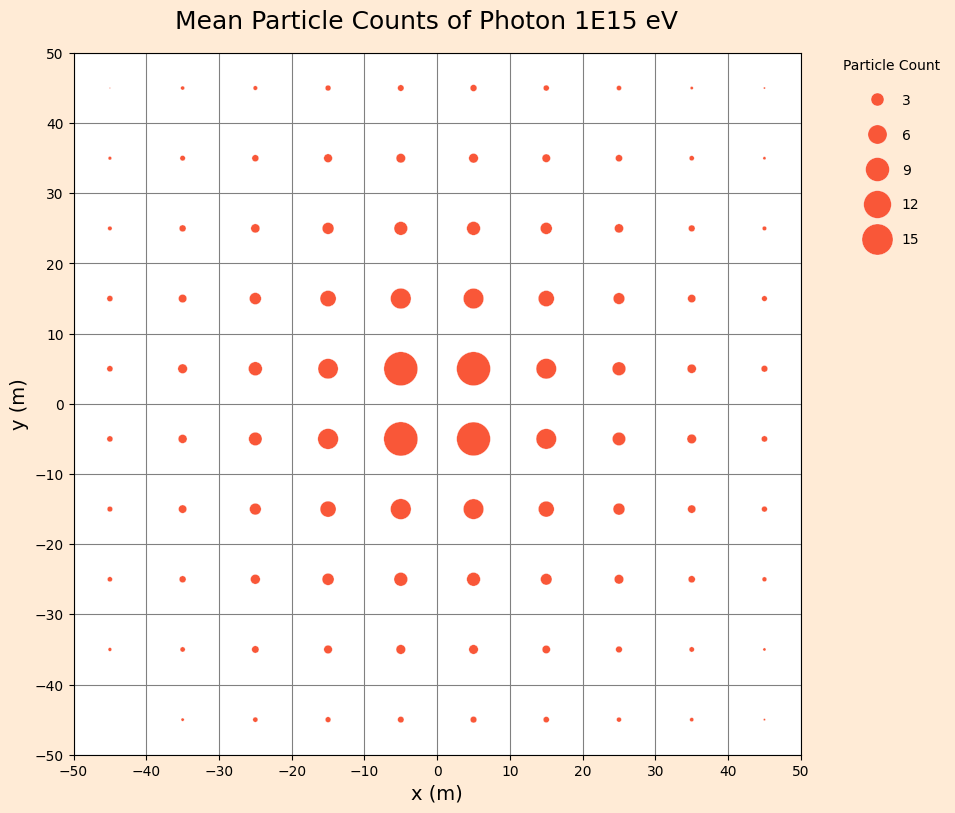

In [57]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Mean Particle Counts of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


plt.savefig('plots/counts_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png', bbox_inches = 'tight', dpi = 300)

In [58]:
# O primeiro índice é o trig do tanque, e o segundo é o evento. Apenas um exemplo
#df2['count'][0][0]*x_det[0]+df2['count'][1][0]*x_det[1]+ df2['count'][2][0]*x_det[2]/(df2['count'][0][0]+df2['count'][1][0]+df2['count'][2][0])

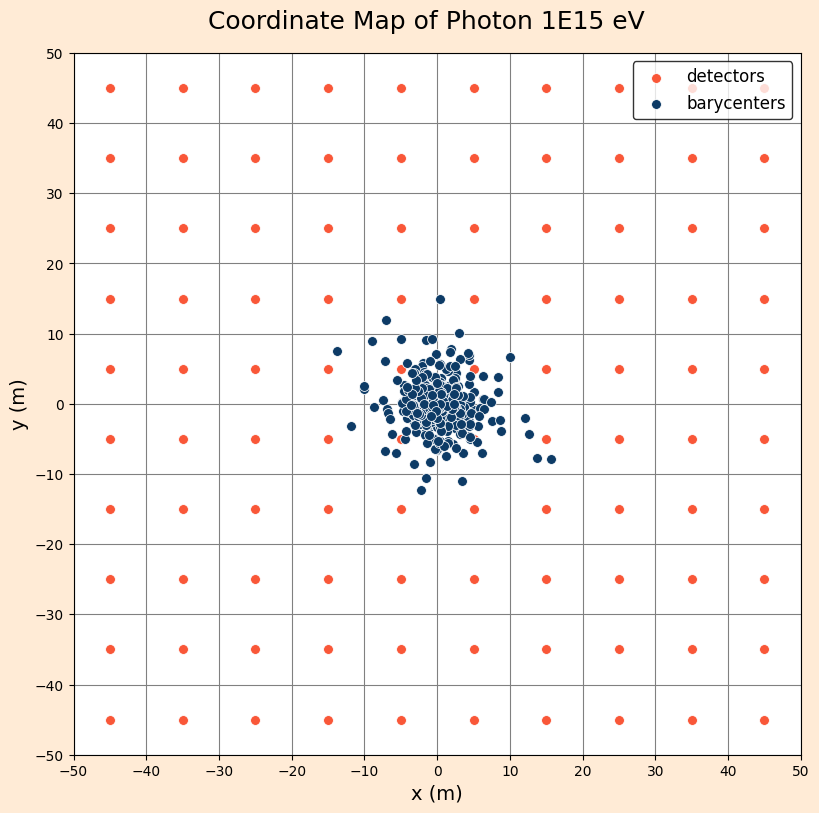

In [59]:
# Posição dos baricentros
x_b = [0] * len(valid_simulations)
y_b = [0] * len(valid_simulations)
rho = []

for i in range(len(valid_simulations)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (triangulation_particles['triangulation_particles'][j][i]*x_det[j])
                numerator1 += (triangulation_particles['triangulation_particles'][j][i]*y_det[j])
                denominator += (triangulation_particles['triangulation_particles'][j][i])
                rho.append((triangulation_particles['triangulation_particles'][j][i])/10000)
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('plots/map_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png',bbox_inches = 'tight', dpi = 300)

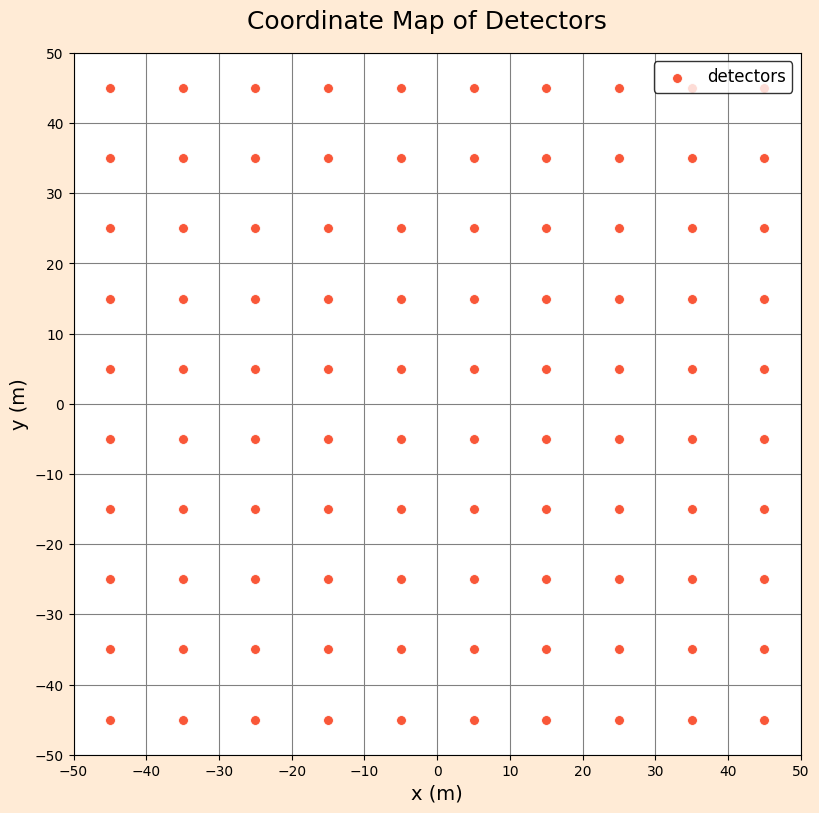

In [60]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

In [61]:
# Criação de arquivo de dados para construir a função de distribuição lateral

r_b = [] 

# Estruturação da lista rho para 100 tanques
rho_reshaped = np.array(rho).reshape(len(x_b), 100)


for i in range(len(valid_simulations)):
    #aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    aux = x_b[i]** 2 + y_b[i]**2
    r_b.append(aux)

data = {
    'x_b':x_b,
    'y_b':y_b,
    'r_b':r_b
}

for i in range(100):
    data[f'rho_{i+1}'] = rho_reshaped[:, i].tolist()

df = pl.DataFrame(data, strict=False)
df

x_b,y_b,r_b,rho_1,rho_2,rho_3,rho_4,rho_5,rho_6,rho_7,rho_8,rho_9,rho_10,rho_11,rho_12,rho_13,rho_14,rho_15,rho_16,rho_17,rho_18,rho_19,rho_20,rho_21,rho_22,rho_23,rho_24,rho_25,rho_26,rho_27,rho_28,rho_29,rho_30,rho_31,rho_32,rho_33,rho_34,…,rho_64,rho_65,rho_66,rho_67,rho_68,rho_69,rho_70,rho_71,rho_72,rho_73,rho_74,rho_75,rho_76,rho_77,rho_78,rho_79,rho_80,rho_81,rho_82,rho_83,rho_84,rho_85,rho_86,rho_87,rho_88,rho_89,rho_90,rho_91,rho_92,rho_93,rho_94,rho_95,rho_96,rho_97,rho_98,rho_99,rho_100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-10.0,2.142857,104.591837,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0001,0.0,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-1.213592,-1.456311,3.593647,0.0,0.0,0.0002,0.0002,0.0,0.0001,0.0001,0.0,0.0,0.0001,0.0,0.0002,0.0,0.0002,0.0,0.0003,0.0001,0.0,0.0001,0.0,0.0,0.0002,0.0001,0.0004,0.0005,0.0007,0.0001,0.0002,0.0,0.0001,0.0,0.0001,0.0002,0.0003,…,0.0002,0.0012,0.0006,0.0004,0.0,0.0001,0.0002,0.0001,0.0001,0.0001,0.0005,0.0003,0.0001,0.0,0.0001,0.0001,0.0,0.0,0.0,0.0,0.0001,0.0002,0.0001,0.0,0.0,0.0001,0.0001,0.0002,0.0,0.0001,0.0001,0.0,0.0,0.0,0.0,0.0001,0.0
2.5,-1.666667,9.027778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0001,0.0001,0.0,0.0,0.0,0.0001,0.0003,…,0.0002,0.0001,0.0001,0.0001,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,0.0,0.0001,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-1.888889,5.888889,38.246914,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0002,0.0002,0.0,0.0001,0.0,0.0001,0.0,0.0,0.0001,0.0,…,0.0001,0.0002,0.0001,0.0,0.0,0.0001,0.0,0.0,0.0001,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,0.0001,0.0001,0.0002,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0004,0.0,0.0001,0.0,0.0,0.0
-0.381166,-0.762332,0.726437,0.0,0.0001,0.0002,0.0001,0.0002,0.0001,0.0,0.0001,0.0,0.0002,0.0,0.0001,0.0006,0.0005,0.0004,0.0006,0.0007,0.0002,0.0002,0.0001,0.0003,0.0003,0.0002,0.0002,0.0012,0.0008,0.0002,0.0002,0.0001,0.0,0.0002,0.0001,0.0005,0.001,…,0.0007,0.0014,0.0006,0.0009,0.0003,0.0002,0.0003,0.0001,0.0,0.0004,0.0007,0.0006,0.0009,0.0003,0.0003,0.0001,0.0001,0.0001,0.0,0.0002,0.0004,0.0006,0.0006,0.0001,0.0004,0.0002,0.0,0.0001,0.0001,0.0001,0.0,0.0002,0.0002,0.0001,0.0002,0.0,0.0002
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5.740741,-1.666667,35.733882,0.0,0.0,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0002,0.0003,0.0001,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,0.0,0.0,0.0002,0.0,0.0,0.0,0.0,0.0001,0.0,0.0001,…,0.0003,0.0,0.0,0.0001,0.0,0.0,0.0002,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-0.139665,-0.977654,0.975313,0.0,0.0,0.0,0.0,0.0002,0.0002,0.0002,0.0001,0.0,0.0002,0.0,0.0001,0.0001,0.0001,0.0002,0.0,0.0,0.0,0.0001,0.0,0.0,0.0001,0.0005,0.0002,0.0003,0.0002,0.0001,0.0001,0.0002,0.0001,0.0001,0.0001,0.0001,0.0001,…,0.0,0.0005,0.0005,0.0005,0.0001,0.0,0.0002,0.0,0.0003,0.0,0.0001,0.0001,0.0004,0.0001,0.0002,0.0001,0.0,0.0,0.0001,0.0001,0.0001,0.0002,0.0001,0.0,0.0002,0.0001,0.0,0.0001,0.0001,0.0002,0.0,0.0,0.0001,0.0,0.0001,0.0,0.0
-0.909091,-1.704545,3.731921,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0001,0.0002,0.0001,0.0,0.0,0.0002,0.0,0.0,0.0,0.0001,0.0001,0.0003,0.0,0.0,0.0,0.0,0.0001,0.0003,0.0,0.0,0.0004,…,0.0,0.0003,0.0003,0.0,0.0,0.00

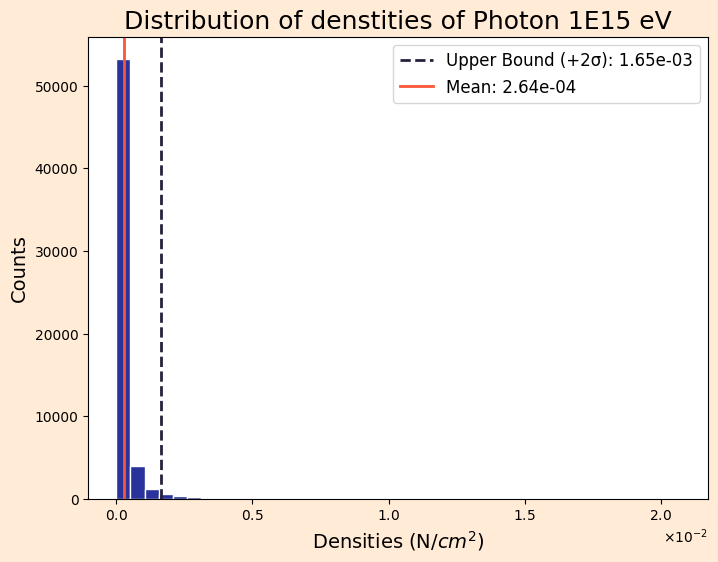

In [ ]:

rho_columns = [f"rho_{i+1}" for i in range(100)] 
values = df.select(rho_columns).to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=40, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)


plt.title('Distribution of denstities of ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Densities (N/$m^2$)', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

In [63]:
from scipy.optimize import curve_fit

# Modelagem NKG
def model(r, C, a, b):
    r0 = 7800
    return C/(r0**2)*(r/r0)**(-a)*(1+r/r0)**(-b)


parameters = []
uncertainties = []
r_squared_list = []
rmse_list = []

x_cols = ['r_b']  
y_cols = [f"rho_{i+1}" for i in range(100)] 

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i]  
    rho = y[i]  
    try:
        popt, pcov = curve_fit(model, r, rho, p0= [2E4, 0.5, 3] , bounds= ([0, 0, 2.5], [np.inf, 1.5, 4.0]))
        perr = np.sqrt(np.diag(pcov))

        # Cálculo das métricas
        y_pred = model(r, *popt)

        # R²
        ss_res = np.sum((rho - y_pred)**2)
        ss_tot = np.sum((rho - np.mean(rho))**2)
        r_sq = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan

        # RMSE
        rmse = np.sqrt(np.mean((rho - y_pred)**2))

        parameters.append(popt)
        uncertainties.append(perr)
        r_squared_list.append(r_sq)
        rmse_list.append(rmse)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])
        r_squared_list.append(np.nan)
        rmse_list.append(np.nan)


# Cria DataFrame com todos os parâmetros
parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    'a': [p[1] for p in parameters],
    'b': [p[2] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    'a_err': [e[1] for e in uncertainties],
    'b_err': [e[2] for e in uncertainties],
    'R_2': r_squared_list,
    'RMSE': rmse_list
})

# Filtra valores válidos para estatísticas
valid = parameters_df.filter(
    pl.all_horizontal(
        pl.col('C').is_not_nan(),
        pl.col('a').is_not_nan(),
        pl.col('b').is_not_nan()
    )
)
print(parameters_df)

print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {valid['C'].mean():.2e} ± {valid['C'].std():.2e}")
print(f"a: Média = {valid['a'].mean():.2f} ± {valid['a'].std():.2f}")
print(f"b: Média = {valid['b'].mean():.2f} ± {valid['b'].std():.2f}")
print(f"R² Médio = {valid['R_2'].mean():.3f} ± {valid['R_2'].std():.3f}")
print(f"RMSE Médio = {valid['RMSE'].mean():.3e} ± {valid['RMSE'].std():.3e}")

shape: (601, 8)
┌─────────────┬──────────┬──────────┬─────────────┬────────────┬───────────┬────────────┬──────────┐
│ C           ┆ a        ┆ b        ┆ C_err       ┆ a_err      ┆ b_err     ┆ R_2        ┆ RMSE     │
│ ---         ┆ ---      ┆ ---      ┆ ---         ┆ ---        ┆ ---       ┆ ---        ┆ ---      │
│ f64         ┆ f64      ┆ f64      ┆ f64         ┆ f64        ┆ f64       ┆ f64        ┆ f64      │
╞═════════════╪══════════╪══════════╪═════════════╪════════════╪═══════════╪════════════╪══════════╡
│ 970.060614  ┆ 0.024252 ┆ 3.951497 ┆ 1.9075e10   ┆ 4.6638e6   ┆ 2.1694e8  ┆ -0.004868  ┆ 0.00004  │
│ 4902.322229 ┆ 0.122558 ┆ 3.754887 ┆ 0.138754    ┆ 5236.41510 ┆ 8.7339e7  ┆ -6.6500e-7 ┆ 0.000301 │
│             ┆          ┆          ┆             ┆ 2          ┆           ┆            ┆          │
│ 1705.248775 ┆ 0.042631 ┆ 3.914738 ┆ 3.2575e10   ┆ 2.8255e6   ┆ 1.0980e8  ┆ -0.000365  ┆ 0.000064 │
│ 2145.941699 ┆ 0.053649 ┆ 3.892703 ┆ 1.2639e11   ┆ 6.9704e7   ┆ 6.5493e10 

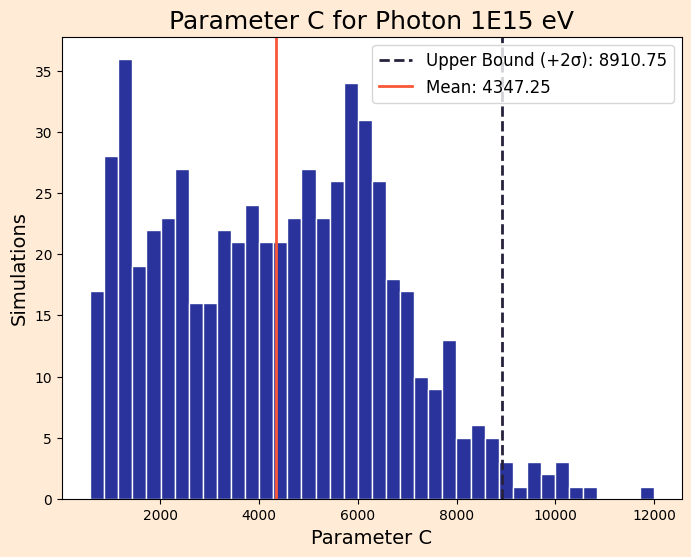

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['C'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('C')
plt.title('Parameter C for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['C'].mean()
std = parameters_df['C'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter C', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_c_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

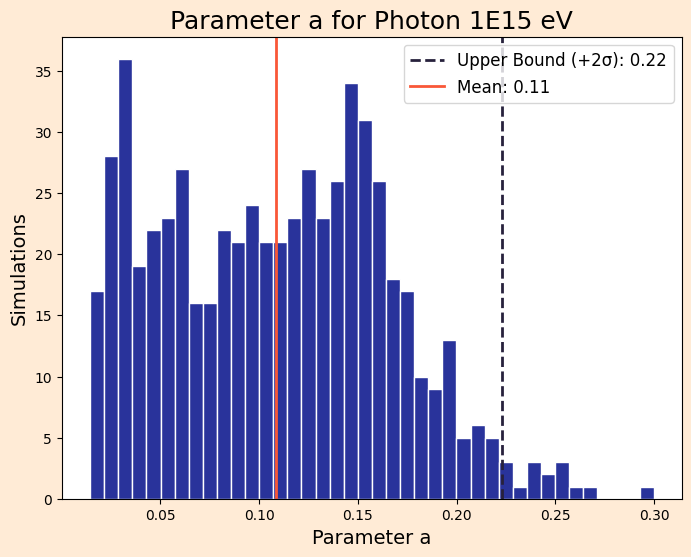

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['a'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter a for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['a'].mean()
std = parameters_df['a'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter a', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/age_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

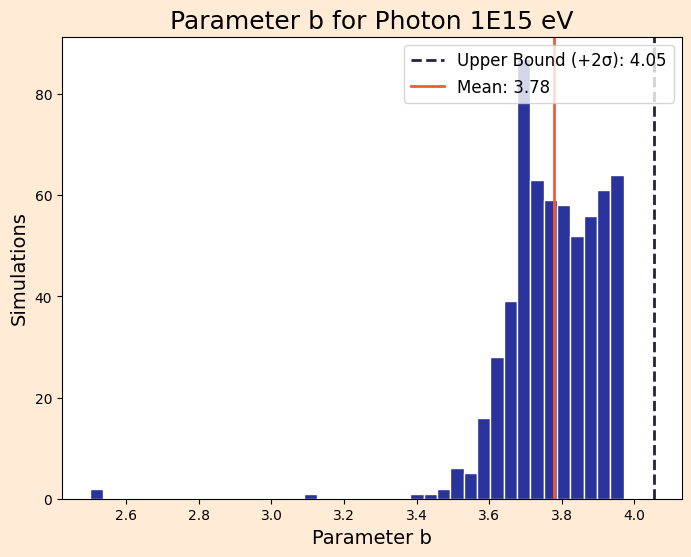

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['b'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter b for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['b'].mean()
std = parameters_df['b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter b', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/age_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

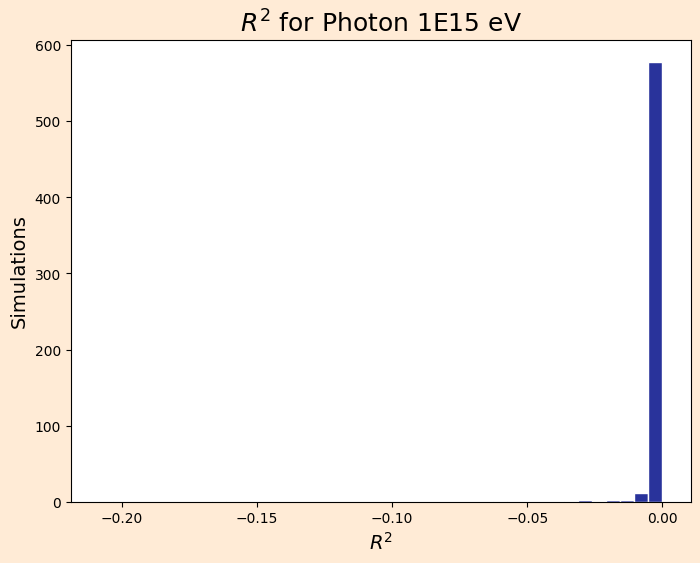

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['R_2'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('$R^2$')
plt.title('$R^2$ for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('$R^2$', size=14)
ax.set_ylabel('Simulations', size=14)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rsquared_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

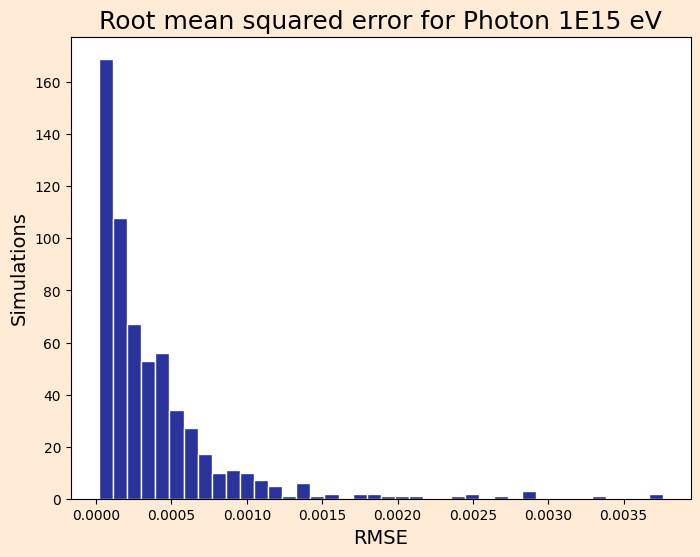

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['RMSE'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('RMSE')
plt.title('Root mean squared error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('RMSE', size=14)
ax.set_ylabel('Simulations', size=14)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rmse_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

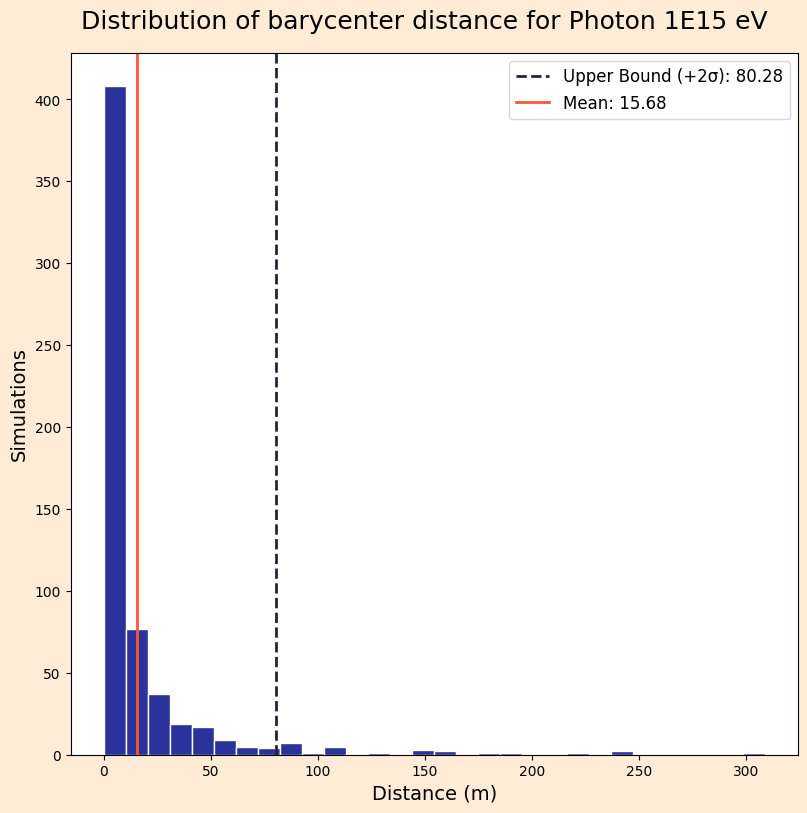

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

plt.hist(df['r_b'], color = '#29339B', edgecolor = 'white', bins = 30)

# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

[4.78456386e-16 1.62405708e-02]
[4.2341922  4.87817914 5.52297264 6.16695958 6.81175308]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_13132\1897768143.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_13132\1897768143.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.207096,15.0,14.978975,0.140167
4.905418,15.499687,15.520823,0.13636
5.541205,16.0,16.014147,0.088417
6.157154,16.499687,16.492079,0.04611
6.803184,17.0,16.993351,0.039112


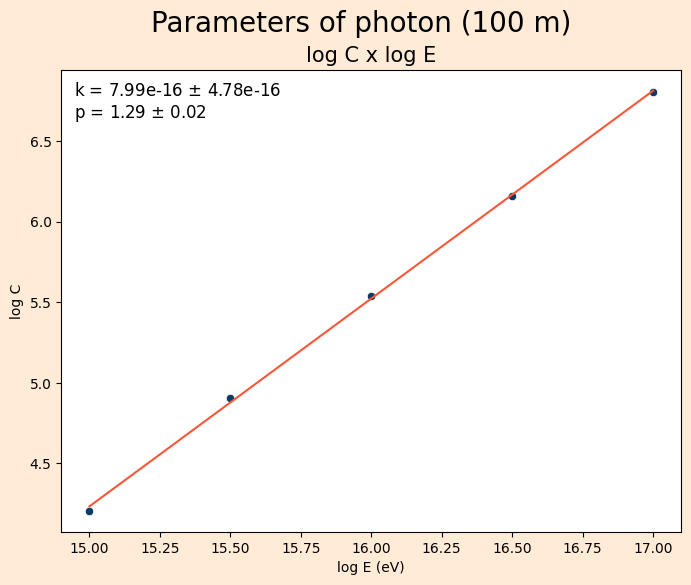

In [ ]:
# Fit do fóton

C = [1.611e+04, 8.043e+04, 3.477e+05, 1.436e+06, 6.356e+06]
E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [ ]:
k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = parameters_df['C'] 

E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_photon)):
    E = (c_photon[i] / k_photon) ** (1 / p_photon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
1.0767e14,89.232537,8.9233e14
3.7849e14,62.15067,6.2151e14
1.6680e14,83.319581,8.3320e14
1.9937e14,80.062627,8.0063e14
4.5964e14,54.035948,5.4036e14
…,…,…
2.2007e14,77.992506,7.7993e14
3.3711e14,66.289498,6.6289e14
2.5988e14,74.011714,7.4012e14


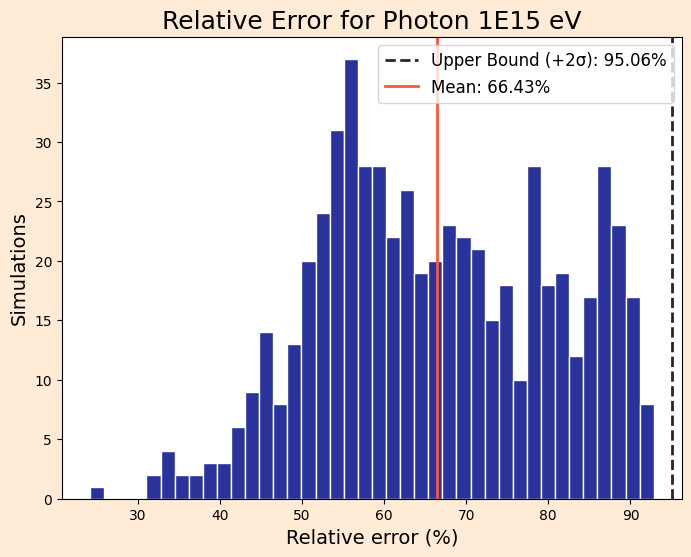

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')

[1.35649802e-13 3.84310014e-03]
[4.62103782 5.21341874 5.8065416 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\184948920.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\184948920.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.619928,14.0,13.999064,0.006689
5.215638,14.499687,14.501559,0.012908
5.805433,15.0,14.999065,0.006235


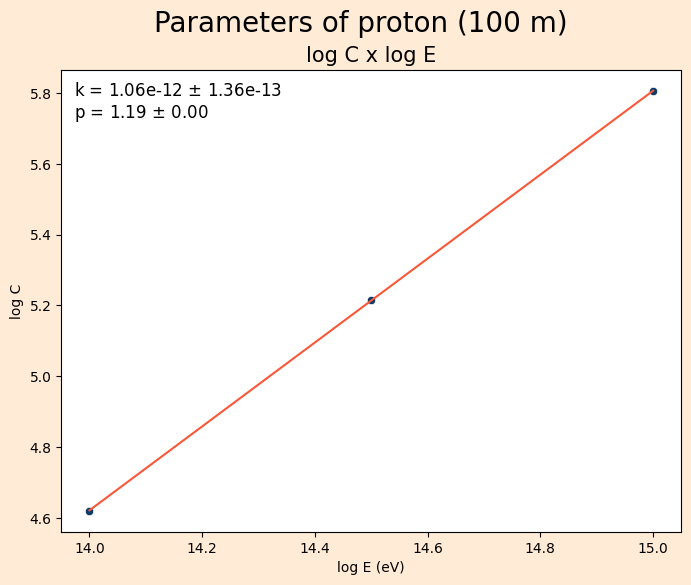

In [15]:
# Fit do próton
from scipy.optimize import curve_fit

C = [4.168e+04, 1.643e+05, 6.389e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_proton))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.12202004e-06 2.38934361e-01]
[4.27281222 4.66000189 5.04767649]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\3661086127.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\3661086127.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.34183,14.0,14.089071,0.636221
4.522053,14.499687,14.321657,1.22782
5.116608,15.0,15.088959,0.593061


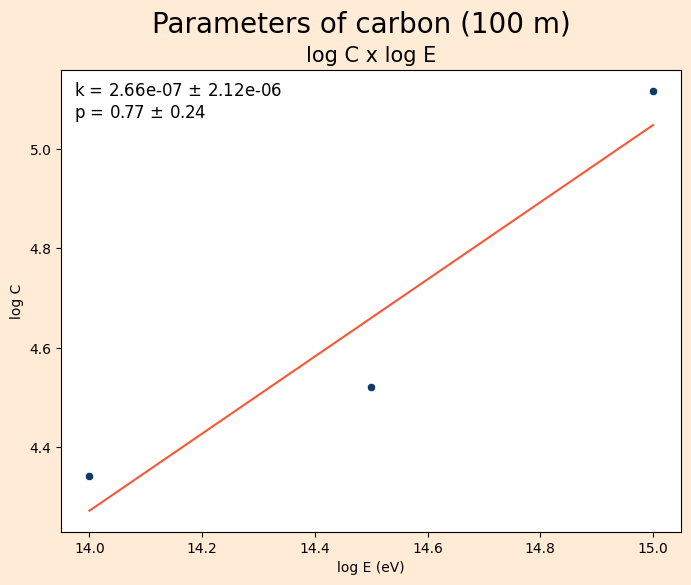

In [16]:
# Fit do carbono
from scipy.optimize import curve_fit

C = [2.197e+04, 3.327e+04, 1.308e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_carbon))

ax.plot(logE, power(E,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_carbon[0]))/coefficients_carbon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[6.16995911e-16 8.87504152e-02]
[3.71289752 4.40512596 5.09822138]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\3240931431.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\3240931431.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.687261,14.0,13.981494,0.132182
4.456366,14.499687,14.536675,0.255094
5.072617,15.0,14.981518,0.123215


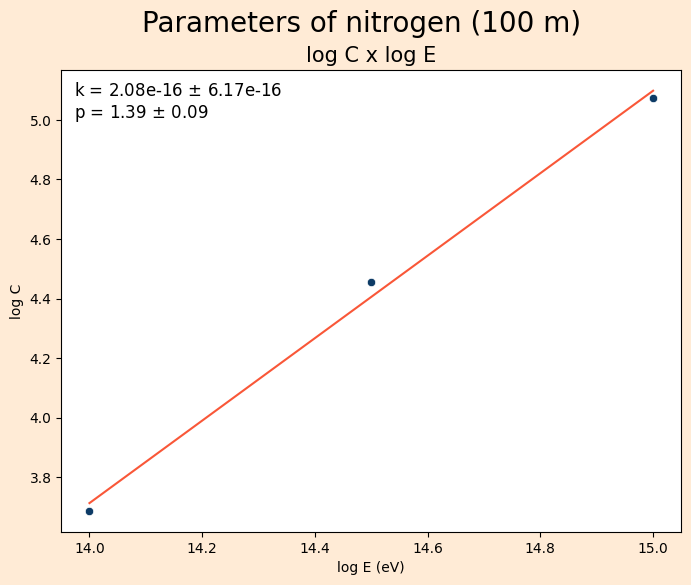

In [17]:
# Fit do nitrogênio
from scipy.optimize import curve_fit

C = [4867, 2.86e+04, 1.182e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_nitrogen))

ax.plot(logE, power(E,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_nitrogen[0]))/coefficients_nitrogen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[3.30510011e-16 2.46194254e-02]
[3.7298276  4.41245988 5.09594713]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\1506402242.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\1506402242.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.722716,14.0,13.994794,0.037183
4.426674,14.499687,14.510092,0.071758
5.088845,15.0,14.994801,0.034661


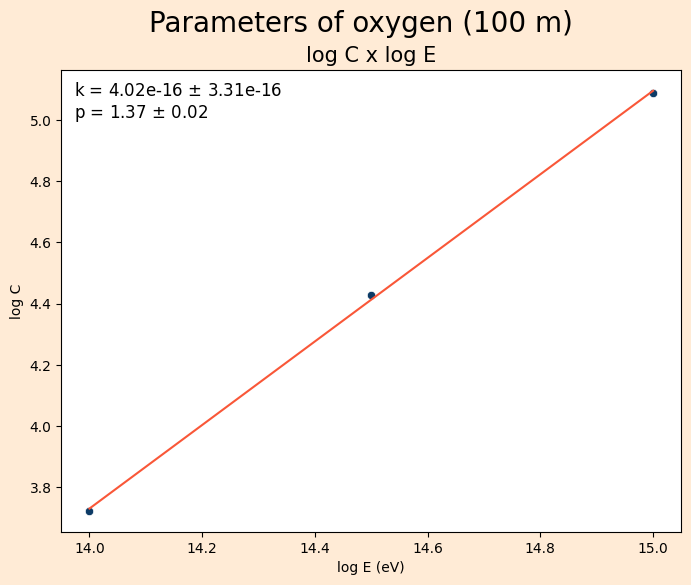

In [18]:
# Fit do oxigênio
from scipy.optimize import curve_fit

C = [5281, 2.671e+04, 1.227e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of oxygen (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_oxygen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_oxygen))

ax.plot(logE, power(E,*coefficients_oxygen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_oxygen[0],inc[0],coefficients_oxygen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_oxygen[0]))/coefficients_oxygen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.35395954e-15 3.98679384e-02]
[4.06730312 4.73902106 5.4115803 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\3778982861.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_12588\3778982861.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.078819,14.0,14.008567,0.061191
4.716003,14.499687,14.482564,0.11809
5.423082,15.0,15.008556,0.05704


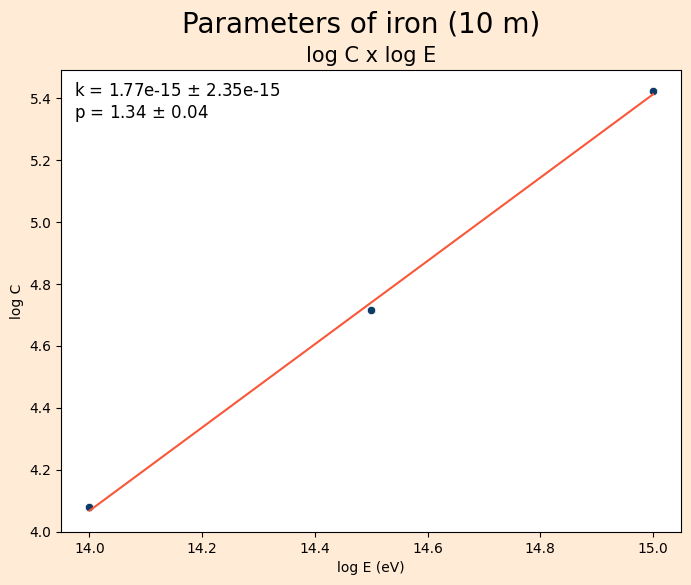

In [19]:
# Fit do ferro
from scipy.optimize import curve_fit

C = [1.199e+04, 5.2e+04, 2.649e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_iron))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [20]:
# Reconstrução da energia

E_real = [1E14, 3.16E14, 1E15]
r0 = 7800

# Parâmetros fóton

k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = [476.7,2411,1.293e+04] 
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)


# Parâmetros próton

k_proton = coefficients_proton[0]
p_proton = coefficients_proton[1]
c_proton = [566.7,2740,1.248e+04]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)

# Parâmetros carbono

k_carbon = coefficients_carbon[0]
p_carbon = coefficients_carbon[1]
c_carbon = [158.1,861,6107]
E_carbon = []

for i in range(len(c_photon)):
    E = (c_carbon[i]/k_carbon)**(1/p_carbon)
    E_carbon.append(E)

# Parâmetros nitrogênio

k_nitrogen = coefficients_nitrogen[0]
p_nitrogen = coefficients_nitrogen[1]
c_nitrogen = [130.5,939.6,4829]
E_nitrogen = []

for i in range(len(c_photon)):
    E = (c_nitrogen[i]/k_nitrogen)**(1/p_nitrogen)
    E_nitrogen.append(E)

# Parâmetros oxigênio

k_oxygen = coefficients_oxygen[0]
p_oxygen = coefficients_oxygen[1]
c_oxygen = [132.3,775.1,5115]
E_oxygen = []

for i in range(len(c_photon)):
    E = (c_oxygen[i]/k_oxygen)**(1/p_oxygen)
    E_oxygen.append(E)

# Parâmetros ferro

k_iron = coefficients_iron[0]
p_iron = coefficients_iron[1]
c_iron = [36.59,294.4,2545]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_carbon':E_carbon,
    'E_nitrogen':E_nitrogen,
    'E_oxygen':E_oxygen,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_carbon,E_nitrogen,E_oxygen,E_iron
f64,f64,f64,f64,f64,f64,f64
1.0000e14,5.3050e12,2.6581e12,2.1065e11,7.0306e12,6.6489e12,1.3719e12
3.1600e14,1.7443e13,1.0043e13,1.8771e12,2.9232e13,2.4254e13,6.4712e12
1.0000e15,5.9873e13,3.6083e13,2.3525e13,9.5288e13,9.6525e13,3.2198e13


[Text(0.5, 1.0, 'Energy relative diviation $\\Delta$E/E')]

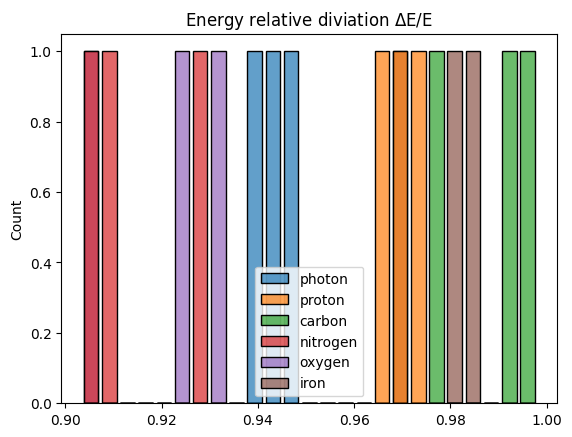

In [21]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_carbon = []
DeltaE_nitrogen = []
DeltaE_oxygen = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = (E_real[i] - E_photon[i])/E_real[i]
    aux2 = (E_real[i] - E_proton[i])/E_real[i]
    aux3 = (E_real[i] - E_carbon[i])/E_real[i]
    aux4 = (E_real[i] - E_nitrogen[i])/E_real[i]
    aux5 = (E_real[i] - E_oxygen[i])/E_real[i]
    aux6 = (E_real[i] - E_iron[i])/E_real[i]
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_carbon.append(aux3)
    DeltaE_nitrogen.append(aux4)
    DeltaE_oxygen.append(aux5)
    DeltaE_iron.append(aux6)

data = {
    'photon':DeltaE_photon,
    'proton':DeltaE_proton,
    'carbon':DeltaE_carbon,
    'nitrogen':DeltaE_nitrogen,
    'oxygen':DeltaE_oxygen,
    'iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy relative diviation $\Delta$E/E')